# Reintegration Readiness Predictor — ML Pipeline

**BYU IS Class Project — Lighthouse Philippines**

This notebook builds both an **explanatory** and **predictive** model to answer:
> *When is a resident ready for reintegration?*

This is the most consequential decision staff make. The model aims to provide a transparent, data-driven readiness score so that social workers can see **why** the model believes a girl is (or is not) ready.

## 1. Problem Framing

**Business Problem:**
Reintegration (returning a girl to family or independent living) is the highest-stakes decision Lighthouse staff make. Currently:
- **19** residents have completed reintegration
- **21** are in progress
- **13** are on hold
- **7** have not started

A premature reintegration puts a girl back into a potentially unsafe environment (**false positive = very dangerous**). Keeping a girl longer than necessary reduces capacity and delays her independence (**false negative = less dangerous but still costly**).

**Modeling Strategy — Two Complementary Approaches:**

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* readiness | Logistic Regression via statsmodels |
| **Predictive** | Predict which residents are ready | Decision Tree Classifier (interpretable rules for staff) |

**Target variable:** `ready` — binary. `1` if `reintegration_status == 'Completed'`, `0` otherwise. Only residents with a non-null `reintegration_status` are included.

**Success metrics:** We want **high recall** (don't miss a girl who is ready) AND **high precision** (don't prematurely reintegrate). F1 score balances both.

**Important limitation:** With only ~60 eligible rows, overfitting is a real risk. We use StratifiedKFold (5 splits) and Leave-One-Out cross-validation throughout, and keep tree depths shallow.

## 2. Data Preparation

The feature matrix is built by joining **7 tables** on `resident_id` — aggregating session, education, health, visitation, intervention, and incident data into per-resident features.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             recall_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ── Load all tables ────────────────────────────────────────────────────────────
DATA_PATH = "../LighthouseData/"
residents = pd.read_csv(DATA_PATH + "residents.csv")
process_recordings = pd.read_csv(DATA_PATH + "process_recordings.csv")
education = pd.read_csv(DATA_PATH + "education_records.csv")
health = pd.read_csv(DATA_PATH + "health_wellbeing_records.csv")
incidents = pd.read_csv(DATA_PATH + "incident_reports.csv")
plans = pd.read_csv(DATA_PATH + "intervention_plans.csv")
visitations = pd.read_csv(DATA_PATH + "home_visitations.csv")

print("Tables loaded:")
for name, frame in [("residents", residents), ("process_recordings", process_recordings),
                     ("education", education), ("health", health), ("incidents", incidents),
                     ("plans", plans), ("visitations", visitations)]:
    print(f"  {name:25s} -> {frame.shape[0]:>5} rows, {frame.shape[1]:>3} cols")

# ── Target variable ────────────────────────────────────────────────────────────
residents['reintegration_status'] = residents['reintegration_status'].replace('None', np.nan)
df = residents[residents['reintegration_status'].notna()].copy()
df['ready'] = (df['reintegration_status'] == 'Completed').astype(int)
print(f"\nEligible residents: {len(df)}")
print(df['reintegration_status'].value_counts().to_string())

# ── Resident-level features ────────────────────────────────────────────────────
risk_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['initial_risk_score'] = df['initial_risk_level'].map(risk_map)
df['current_risk_score'] = df['current_risk_level'].map(risk_map)
df['risk_improvement'] = df['initial_risk_score'] - df['current_risk_score']

sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]
for col in sub_cat_cols:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)
df['abuse_type_count'] = df[sub_cat_cols].sum(axis=1)

for col in ['has_special_needs', 'family_is_4ps', 'family_solo_parent']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
reference_date = pd.Timestamp('2026-04-06')
df['length_of_stay_days'] = (reference_date - df['date_of_admission']).dt.days

# ── Process recording aggregates ───────────────────────────────────────────────
emotion_map = {'Distressed': 1, 'Angry': 2, 'Withdrawn': 3, 'Sad': 4,
               'Anxious': 5, 'Calm': 6, 'Hopeful': 7, 'Happy': 8}
process_recordings['start_score'] = process_recordings['emotional_state_observed'].map(emotion_map)
process_recordings['end_score'] = process_recordings['emotional_state_end'].map(emotion_map)
process_recordings['emotion_change'] = process_recordings['end_score'] - process_recordings['start_score']

pr_agg = process_recordings.groupby('resident_id').agg(
    session_count=('recording_id', 'count'),
    avg_emotion_change=('emotion_change', 'mean'),
    pct_progress_noted=('progress_noted', 'mean'),
    pct_concerns_flagged=('concerns_flagged', 'mean')
).reset_index()

# ── Education aggregates ───────────────────────────────────────────────────────
edu_agg = education.groupby('resident_id').agg(
    avg_attendance_rate=('attendance_rate', 'mean'),
    avg_progress_percent=('progress_percent', 'mean'),
    has_completed_program=('completion_status', lambda x: int((x == 'Completed').any()))
).reset_index()

# ── Health aggregates ──────────────────────────────────────────────────────────
health['record_date'] = pd.to_datetime(health['record_date'])

def health_trend(g):
    g = g.sort_values('record_date')
    if len(g) < 2:
        return 0.0
    return g['general_health_score'].iloc[-1] - g['general_health_score'].iloc[0]

health_trend_series = health.groupby('resident_id').apply(health_trend).reset_index()
health_trend_series.columns = ['resident_id', 'health_trend']

health_agg = health.groupby('resident_id').agg(
    avg_health_score=('general_health_score', 'mean'),
    avg_nutrition_score=('nutrition_score', 'mean')
).reset_index()
health_agg = health_agg.merge(health_trend_series, on='resident_id', how='left')

# ── Visitation aggregates ──────────────────────────────────────────────────────
coop_map = {'Uncooperative': 1, 'Neutral': 2, 'Cooperative': 3, 'Highly Cooperative': 4}
visitations['cooperation_score'] = visitations['family_cooperation_level'].map(coop_map)
visitations['favorable'] = (visitations['visit_outcome'] == 'Favorable').astype(int)
visitations['safety_flag'] = visitations['safety_concerns_noted'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0}
).fillna(0).astype(int)

vis_agg = visitations.groupby('resident_id').agg(
    visit_count=('visitation_id', 'count'),
    avg_cooperation_score=('cooperation_score', 'mean'),
    pct_favorable_outcomes=('favorable', 'mean'),
    pct_safety_concerns=('safety_flag', 'mean')
).reset_index()

# ── Intervention plan aggregates ───────────────────────────────────────────────
plans_agg = plans.groupby('resident_id').agg(
    plan_count=('plan_id', 'count'),
    pct_plans_achieved=('status', lambda x: (x == 'Achieved').mean())
).reset_index()

# ── Incident aggregates ───────────────────────────────────────────────────────
inc_agg = incidents.groupby('resident_id').agg(
    incident_count=('incident_id', 'count'),
    has_self_harm=('incident_type', lambda x: int((x == 'SelfHarm').any())),
    has_runaway=('incident_type', lambda x: int((x == 'RunawayAttempt').any()))
).reset_index()

# ── Merge all features into master dataframe ─────────────────────────────────
for agg_df in [pr_agg, edu_agg, health_agg, vis_agg, plans_agg, inc_agg]:
    df = df.merge(agg_df, on='resident_id', how='left')

feature_cols = [
    'initial_risk_score', 'current_risk_score', 'risk_improvement',
    'abuse_type_count', 'has_special_needs', 'family_is_4ps', 'family_solo_parent',
    'length_of_stay_days',
    'session_count', 'avg_emotion_change', 'pct_progress_noted', 'pct_concerns_flagged',
    'avg_attendance_rate', 'avg_progress_percent', 'has_completed_program',
    'avg_health_score', 'avg_nutrition_score', 'health_trend',
    'visit_count', 'avg_cooperation_score', 'pct_favorable_outcomes', 'pct_safety_concerns',
    'plan_count', 'pct_plans_achieved',
    'incident_count', 'has_self_harm', 'has_runaway'
]

df['case_category'] = df['case_category'].astype(str)
df[feature_cols] = df[feature_cols].fillna(0)

y = df['ready'].values

print(f"\nFeature matrix shape: {df[feature_cols].shape}")
print(f"Target distribution: {np.bincount(y)} (0=not ready, 1=ready)")

Tables loaded:
  residents                 ->    60 rows,  49 cols
  process_recordings        ->  2819 rows,  15 cols
  education                 ->   534 rows,  10 cols
  health                    ->   534 rows,  14 cols
  incidents                 ->   100 rows,  12 cols
  plans                     ->   180 rows,  11 cols
  visitations               ->  1337 rows,  14 cols

Eligible residents: 60
reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7

Feature matrix shape: (60, 27)
Target distribution: [41 19] (0=not ready, 1=ready)


## 3. Exploratory Data Analysis

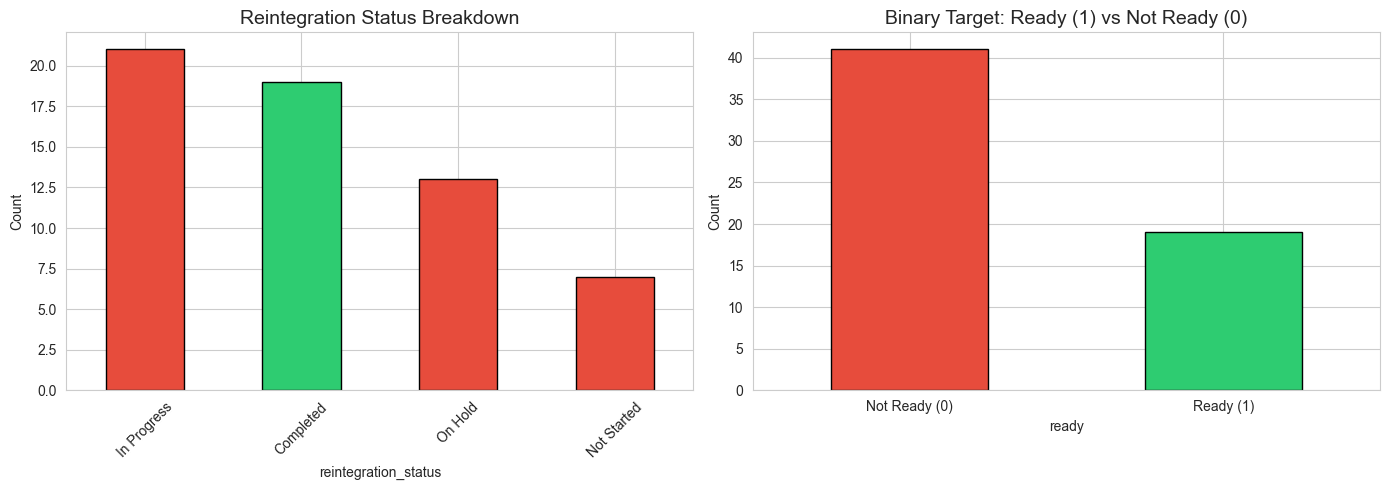

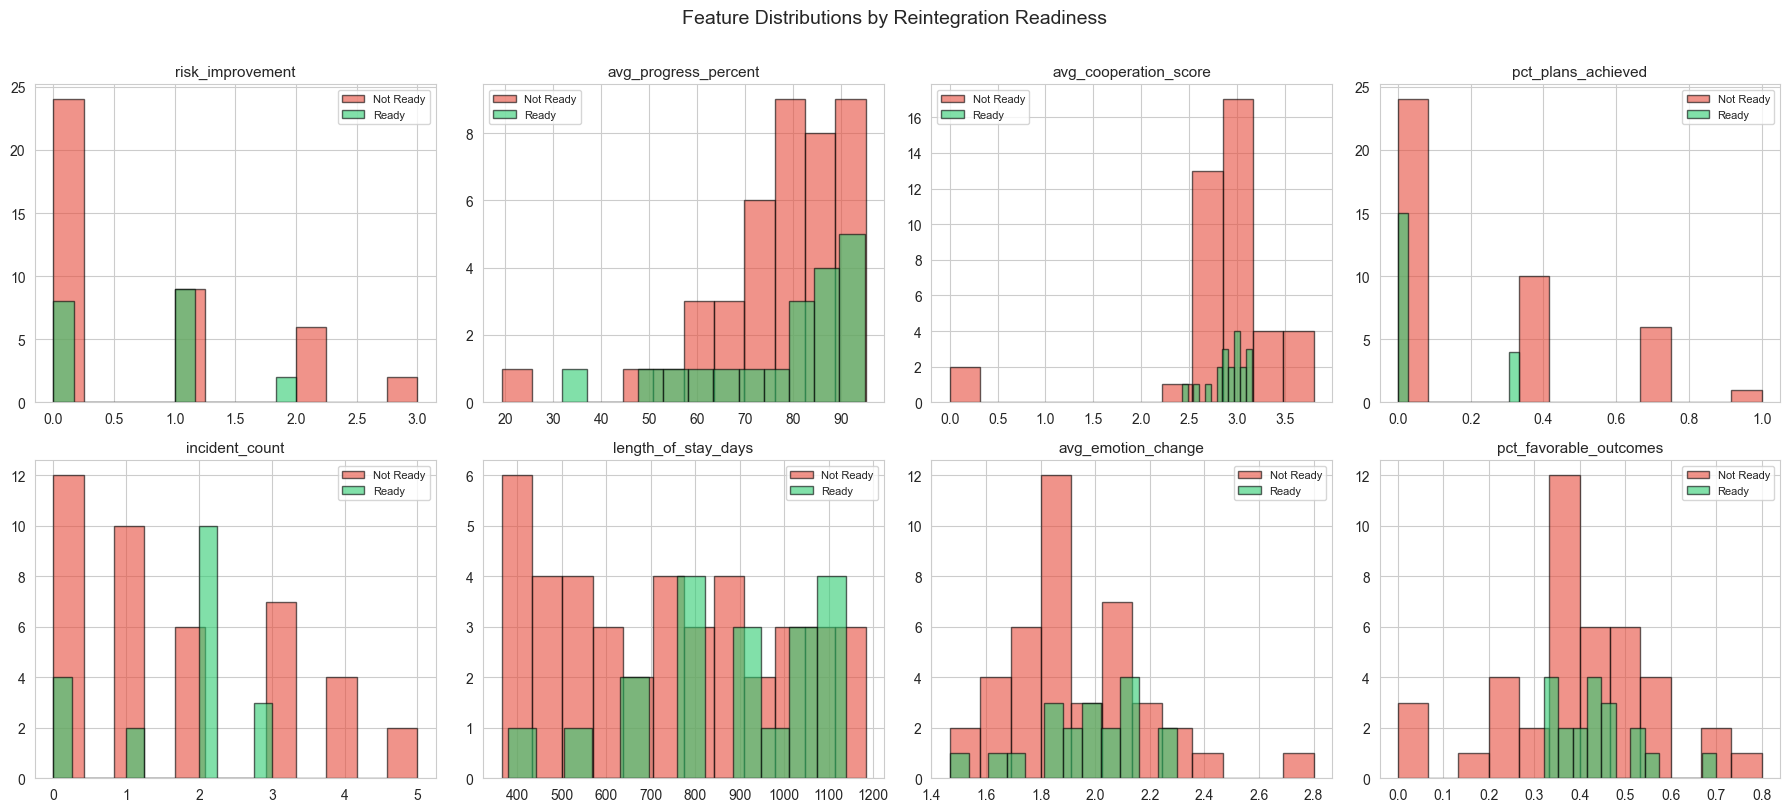

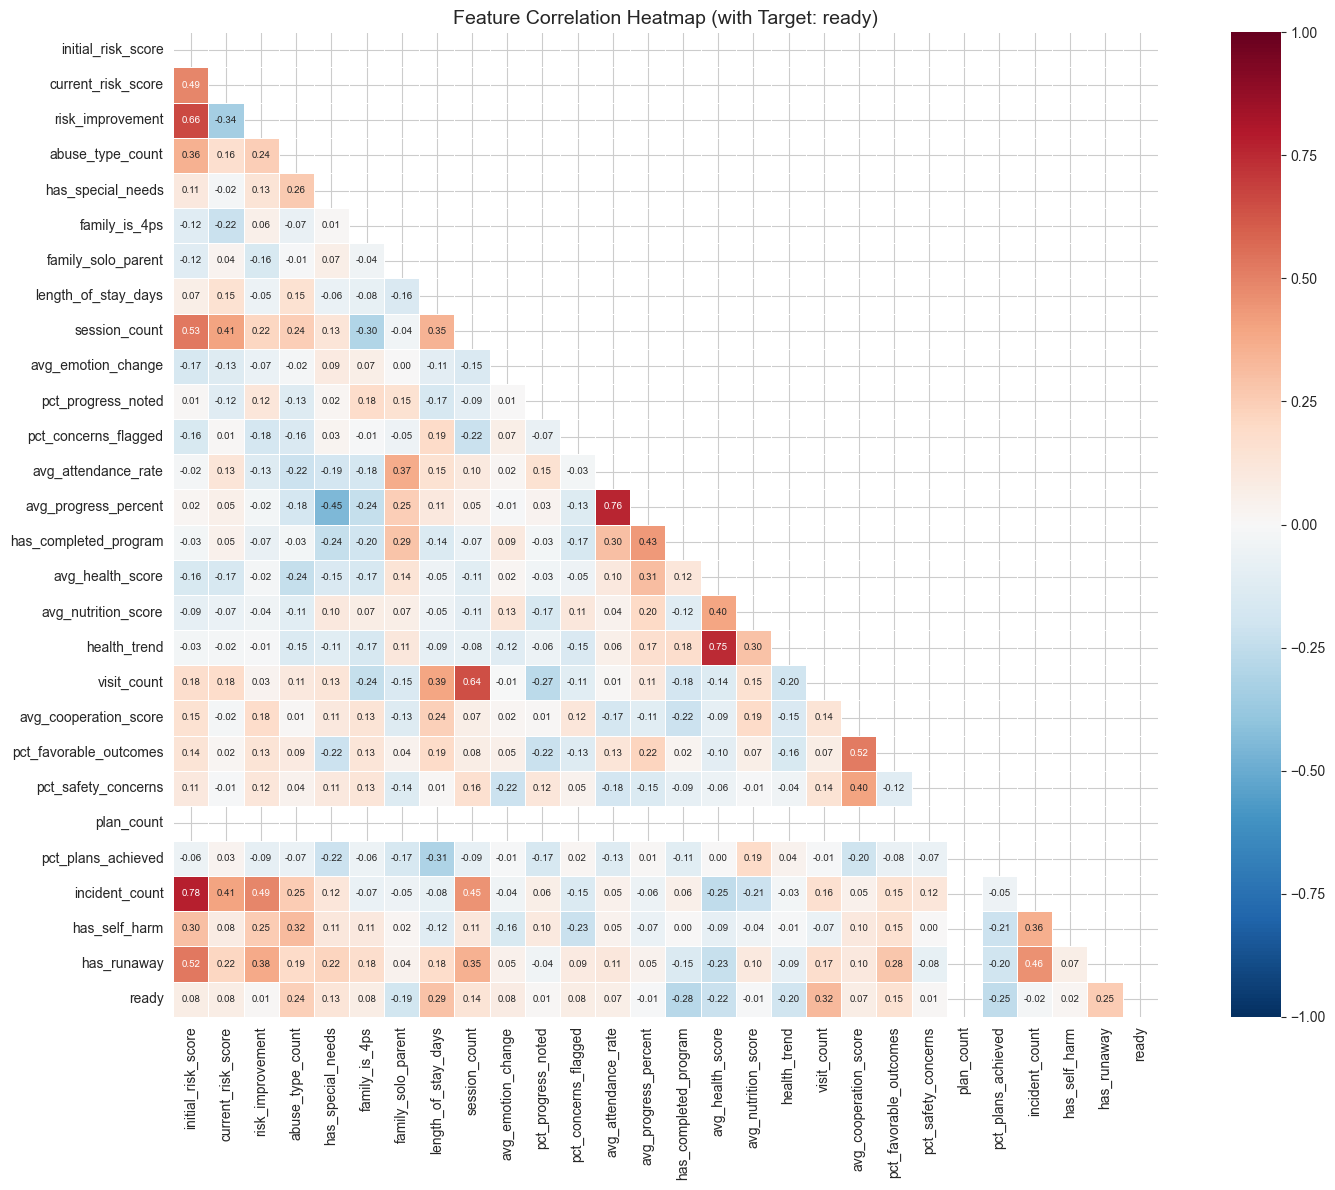

Correlation with target (ready):
visit_count               0.321012
length_of_stay_days       0.289812
has_runaway               0.251643
abuse_type_count          0.235230
pct_favorable_outcomes    0.149727
session_count             0.137577
has_special_needs         0.131372
avg_emotion_change        0.083345
pct_concerns_flagged      0.077756
current_risk_score        0.077448
family_is_4ps             0.075738
initial_risk_score        0.075298
avg_cooperation_score     0.070942
avg_attendance_rate       0.065859
has_self_harm             0.017914
risk_improvement          0.014389
pct_safety_concerns       0.011374
pct_progress_noted        0.009924
avg_progress_percent     -0.008352
avg_nutrition_score      -0.014471
incident_count           -0.017379
family_solo_parent       -0.190151
health_trend             -0.196006
avg_health_score         -0.220483
pct_plans_achieved       -0.250478
has_completed_program    -0.278682
plan_count                     NaN


In [2]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df['reintegration_status'].value_counts()
colors = ['#2ecc71' if s == 'Completed' else '#e74c3c' for s in status_counts.index]
status_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Reintegration Status Breakdown', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['ready'].value_counts().reindex([0, 1]).plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[1].set_title('Binary Target: Ready (1) vs Not Ready (0)', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Not Ready (0)', 'Ready (1)'], rotation=0)
plt.tight_layout()
plt.show()

# ── Feature distributions by target ───────────────────────────────────────────
key_features = ['risk_improvement', 'avg_progress_percent', 'avg_cooperation_score',
                'pct_plans_achieved', 'incident_count', 'length_of_stay_days',
                'avg_emotion_change', 'pct_favorable_outcomes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(key_features):
    ax = axes[i // 4, i % 4]
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        subset = df[df['ready'] == label][feat].dropna()
        ax.hist(subset, bins=12, alpha=0.6, color=color,
                label='Ready' if label == 1 else 'Not Ready', edgecolor='black')
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Reintegration Readiness', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Correlation heatmap ────────────────────────────────────────────────────────
corr_cols = feature_cols + ['ready']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (with Target: ready)', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation with target (ready):")
print(corr_matrix['ready'].drop('ready').sort_values(ascending=False).to_string())

## 4. Explanatory Model — statsmodels Logistic Regression

In [3]:
# ── Prepare scaled features for logit ─────────────────────────────────────────
X_raw = df[feature_cols].copy()
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols, index=X_raw.index)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=feature_cols, index=X_raw.index)

# ── Explanatory: statsmodels Logit with try/except bfgs ─────────────────────
X_exp = sm.add_constant(X_scaled)
try:
    logit = sm.Logit(y, X_exp).fit(method='bfgs', maxiter=100, disp=0)
    print(logit.summary())
except Exception as e:
    print(f'Logit failed ({e}). Using regularized fit...')
    logit = sm.Logit(y, X_exp).fit_regularized(method='l1', alpha=0.1, disp=0)
    print(logit.summary())

sig = logit.pvalues[logit.pvalues < 0.10].drop('const', errors='ignore')
if len(sig) > 0:
    print("\n--- Features significant at p < 0.10 ---")
    for feat, pval in sig.items():
        coef = logit.params[feat]
        direction = "increases" if coef > 0 else "decreases"
        print(f"  {feat}: coef={coef:.3f}, p={pval:.4f} -- {direction} readiness probability")
else:
    print("\nNo features significant at p < 0.10 (expected with ~60 rows and many features).")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   60
Model:                          Logit   Df Residuals:                       34
Method:                           MLE   Df Model:                           25
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        20:37:22   Log-Likelihood:            -0.00020659
converged:                       True   LL-Null:                       -37.460
Covariance Type:            nonrobust   LLR p-value:                 6.980e-07
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -1130.3812        nan        nan        nan         nan         nan
initial_risk_score      2303.0700        nan        nan        nan         nan         nan
curr

## 5. Predictive Model — Decision Tree Depth Sweep + Model Comparison

Decision Tree Depth Sweep Results:
 depth  skf_accuracy   skf_f1  skf_recall  skf_precision  loo_accuracy   loo_f1  loo_recall  loo_precision
     1      0.616667 0.325758    0.366667       0.302381      0.650000 0.183333    0.183333       0.183333
     2      0.716667 0.483550    0.466667       0.614286      0.633333 0.183333    0.183333       0.183333
     3      0.683333 0.390476    0.316667       0.566667      0.650000 0.133333    0.133333       0.133333
     4      0.700000 0.400000    0.316667       0.600000      0.600000 0.150000    0.150000       0.150000
     5      0.650000 0.377778    0.316667       0.540000      0.600000 0.133333    0.133333       0.133333
     6      0.666667 0.383333    0.316667       0.550000      0.600000 0.133333    0.133333       0.133333

Best depth by LOO F1: 1


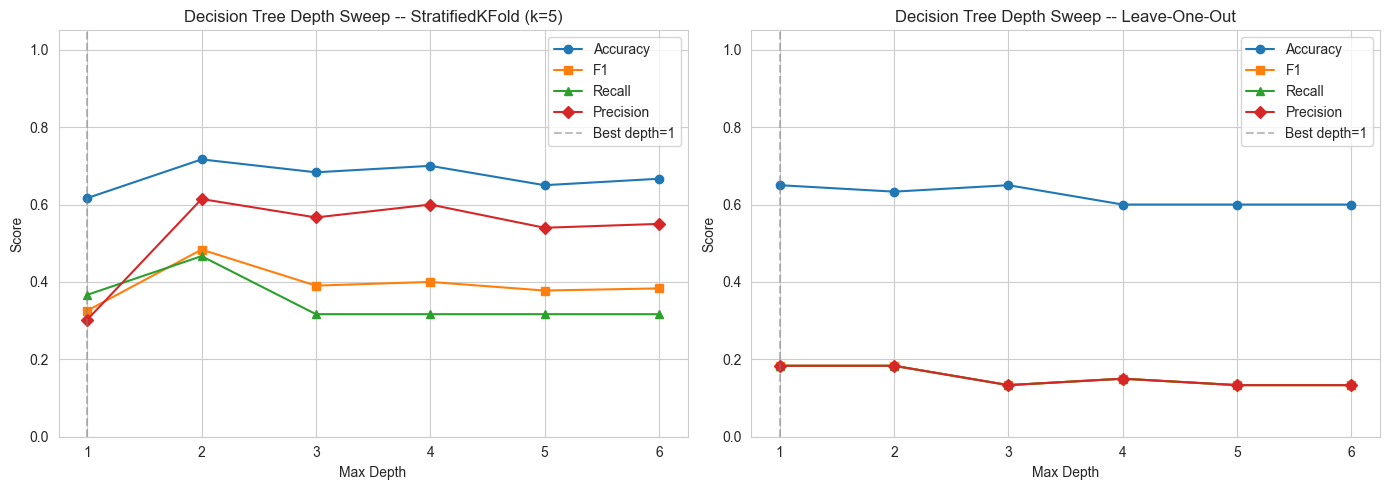

Model Comparison:
              Model    SKF Accuracy          SKF F1 SKF Recall SKF Precision LOO Accuracy LOO F1 LOO Recall LOO Precision
      Decision Tree 0.617 +/- 0.067 0.326 +/- 0.195      0.367         0.302        0.650  0.183      0.183         0.183
Logistic Regression 0.583 +/- 0.091 0.267 +/- 0.146      0.267         0.367        0.633  0.117      0.117         0.117
      Random Forest 0.617 +/- 0.113 0.210 +/- 0.180      0.167         0.350        0.667  0.033      0.033         0.033
  Gradient Boosting 0.650 +/- 0.082 0.363 +/- 0.083      0.317         0.450        0.683  0.117      0.117         0.117


In [4]:
# ── Build preprocessing pipeline ───────────────────────────────────────────────
numeric_features = feature_cols
categorical_features = ['case_category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_full = df[numeric_features + categorical_features].copy()

# ── Decision Tree depth sweep ──────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
loo = LeaveOneOut()

depth_results = []
for depth in range(1, 7):
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    cv_skf = cross_validate(pipe, X_full, y, cv=skf,
                            scoring=['accuracy', 'f1', 'recall', 'precision'],
                            return_train_score=False)
    cv_loo = cross_validate(pipe, X_full, y, cv=loo,
                            scoring=['accuracy', 'f1', 'recall', 'precision'],
                            return_train_score=False)
    depth_results.append({
        'depth': depth,
        'skf_accuracy': cv_skf['test_accuracy'].mean(),
        'skf_f1': cv_skf['test_f1'].mean(),
        'skf_recall': cv_skf['test_recall'].mean(),
        'skf_precision': cv_skf['test_precision'].mean(),
        'loo_accuracy': cv_loo['test_accuracy'].mean(),
        'loo_f1': cv_loo['test_f1'].mean(),
        'loo_recall': cv_loo['test_recall'].mean(),
        'loo_precision': cv_loo['test_precision'].mean(),
    })

depth_df = pd.DataFrame(depth_results)
print("Decision Tree Depth Sweep Results:")
print(depth_df.to_string(index=False))
best_depth = depth_df.loc[depth_df['loo_f1'].idxmax(), 'depth']
print(f"\nBest depth by LOO F1: {int(best_depth)}")

# ── Depth sweep visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prefix, title in [(axes[0], 'skf_', 'StratifiedKFold (k=5)'),
                           (axes[1], 'loo_', 'Leave-One-Out')]:
    ax.plot(depth_df['depth'], depth_df[f'{prefix}accuracy'], 'o-', label='Accuracy')
    ax.plot(depth_df['depth'], depth_df[f'{prefix}f1'], 's-', label='F1')
    ax.plot(depth_df['depth'], depth_df[f'{prefix}recall'], '^-', label='Recall')
    ax.plot(depth_df['depth'], depth_df[f'{prefix}precision'], 'D-', label='Precision')
    ax.axvline(x=best_depth, color='gray', linestyle='--', alpha=0.5, label=f'Best depth={int(best_depth)}')
    ax.set_xlabel('Max Depth'); ax.set_ylabel('Score')
    ax.set_title(f'Decision Tree Depth Sweep -- {title}', fontsize=12)
    ax.legend(); ax.set_xticks(range(1, 7)); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ── Compare all classifiers ────────────────────────────────────────────────────
models = {
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=int(best_depth), random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))
    ]),
}

results = []
for name, pipe in models.items():
    cv_skf = cross_validate(pipe, X_full, y, cv=skf,
                            scoring=['accuracy', 'f1', 'recall', 'precision'],
                            return_train_score=False)
    cv_loo = cross_validate(pipe, X_full, y, cv=loo,
                            scoring=['accuracy', 'f1', 'recall', 'precision'],
                            return_train_score=False)
    results.append({
        'Model': name,
        'SKF Accuracy': f"{cv_skf['test_accuracy'].mean():.3f} +/- {cv_skf['test_accuracy'].std():.3f}",
        'SKF F1': f"{cv_skf['test_f1'].mean():.3f} +/- {cv_skf['test_f1'].std():.3f}",
        'SKF Recall': f"{cv_skf['test_recall'].mean():.3f}",
        'SKF Precision': f"{cv_skf['test_precision'].mean():.3f}",
        'LOO Accuracy': f"{cv_loo['test_accuracy'].mean():.3f}",
        'LOO F1': f"{cv_loo['test_f1'].mean():.3f}",
        'LOO Recall': f"{cv_loo['test_recall'].mean():.3f}",
        'LOO Precision': f"{cv_loo['test_precision'].mean():.3f}",
    })

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df.to_string(index=False))

## 6. Decision Tree Visualization

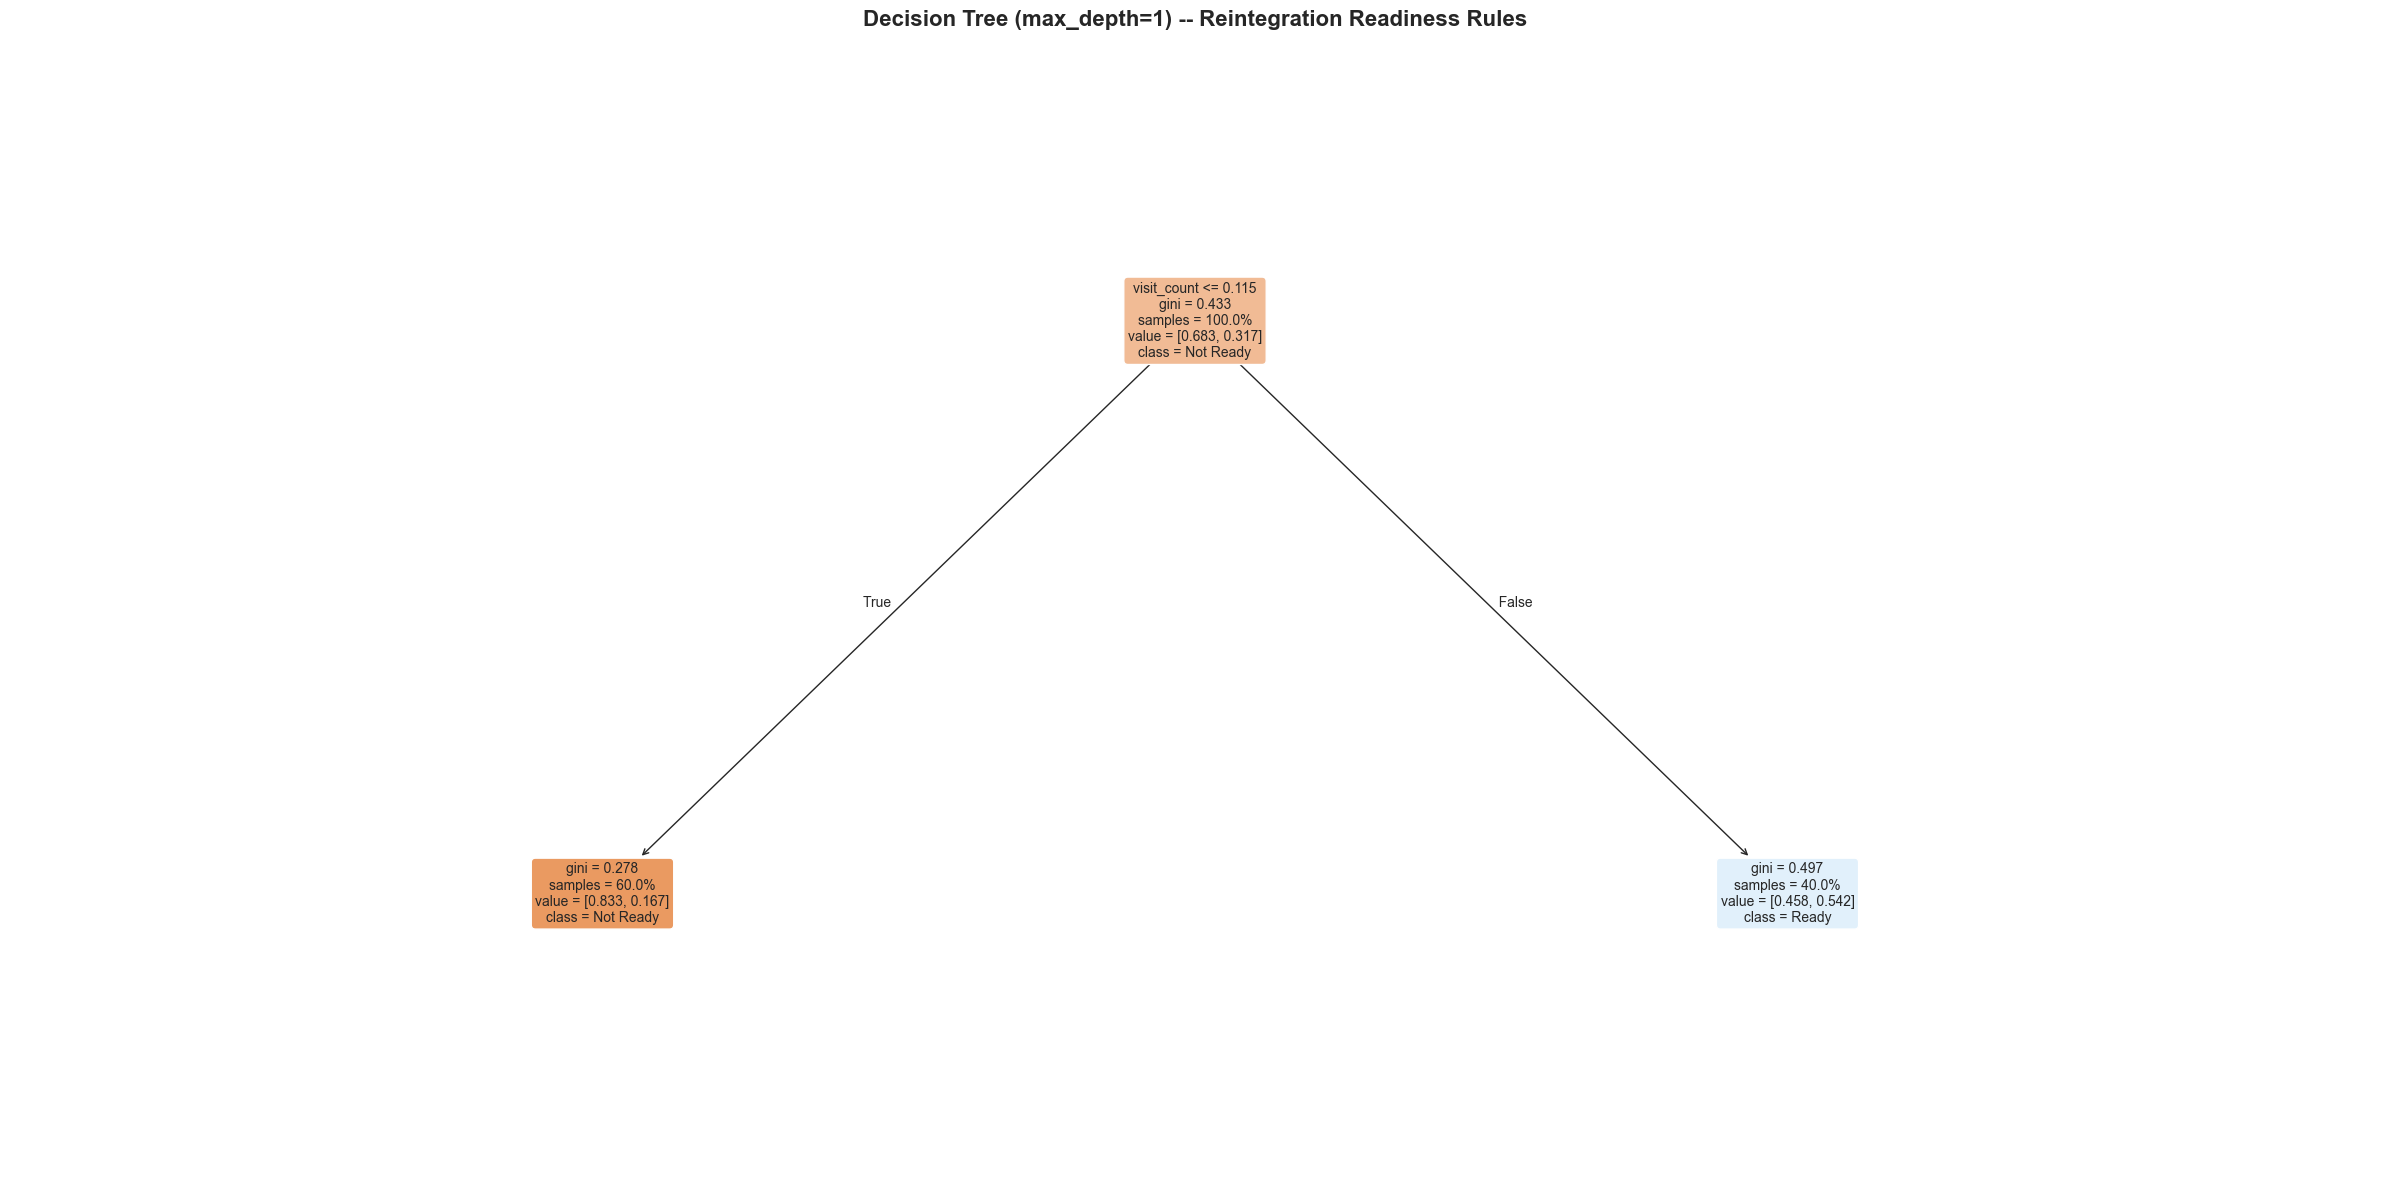

Decision Tree Rules (staff-readable):
|--- visit_count <= 0.12
|   |--- class: 0
|--- visit_count >  0.12
|   |--- class: 1



In [5]:
# ── Fit all models and visualize the Decision Tree ─────────────────────────
for name, pipe in models.items():
    pipe.fit(X_full, y)

# Get feature names after preprocessing
cat_encoder = models['Decision Tree'].named_steps['pre'].named_transformers_['cat'].named_steps['encoder']
cat_encoder.fit(df[categorical_features])
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = feature_cols + cat_feature_names

best_tree_pipe = models['Decision Tree']
best_tree = best_tree_pipe.named_steps['clf']

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    best_tree,
    feature_names=all_feature_names[:len(best_tree.feature_importances_)],
    class_names=['Not Ready', 'Ready'],
    filled=True, rounded=True, fontsize=10, proportion=True, ax=ax
)
ax.set_title(f'Decision Tree (max_depth={int(best_depth)}) -- Reintegration Readiness Rules',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Extract decision rules ─────────────────────────────────────────────────────
tree_rules = export_text(
    best_tree,
    feature_names=all_feature_names[:len(best_tree.feature_importances_)]
)
print("Decision Tree Rules (staff-readable):")
print("=" * 60)
print(tree_rules)
print("=" * 60)

## 7. Evaluation

Full-data Classification Report (for reference -- NOT out-of-sample):
              precision    recall  f1-score   support

   Not Ready       0.83      0.73      0.78        41
       Ready       0.54      0.68      0.60        19

    accuracy                           0.72        60
   macro avg       0.69      0.71      0.69        60
weighted avg       0.74      0.72      0.72        60



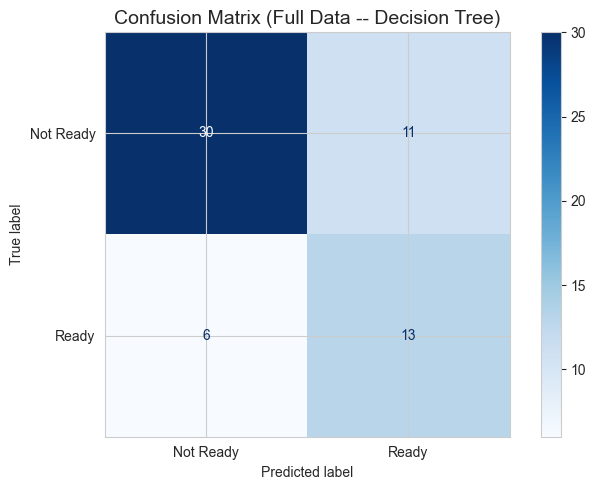

Error cost analysis:
  False Positives (predicted Ready but not): 11
    -> RISK: Premature reintegration -- girl returns to unsafe environment
  False Negatives (predicted Not Ready but is): 6
    -> COST: Girl stays longer than needed -- impacts shelter capacity
  True Positives: 13 | True Negatives: 30


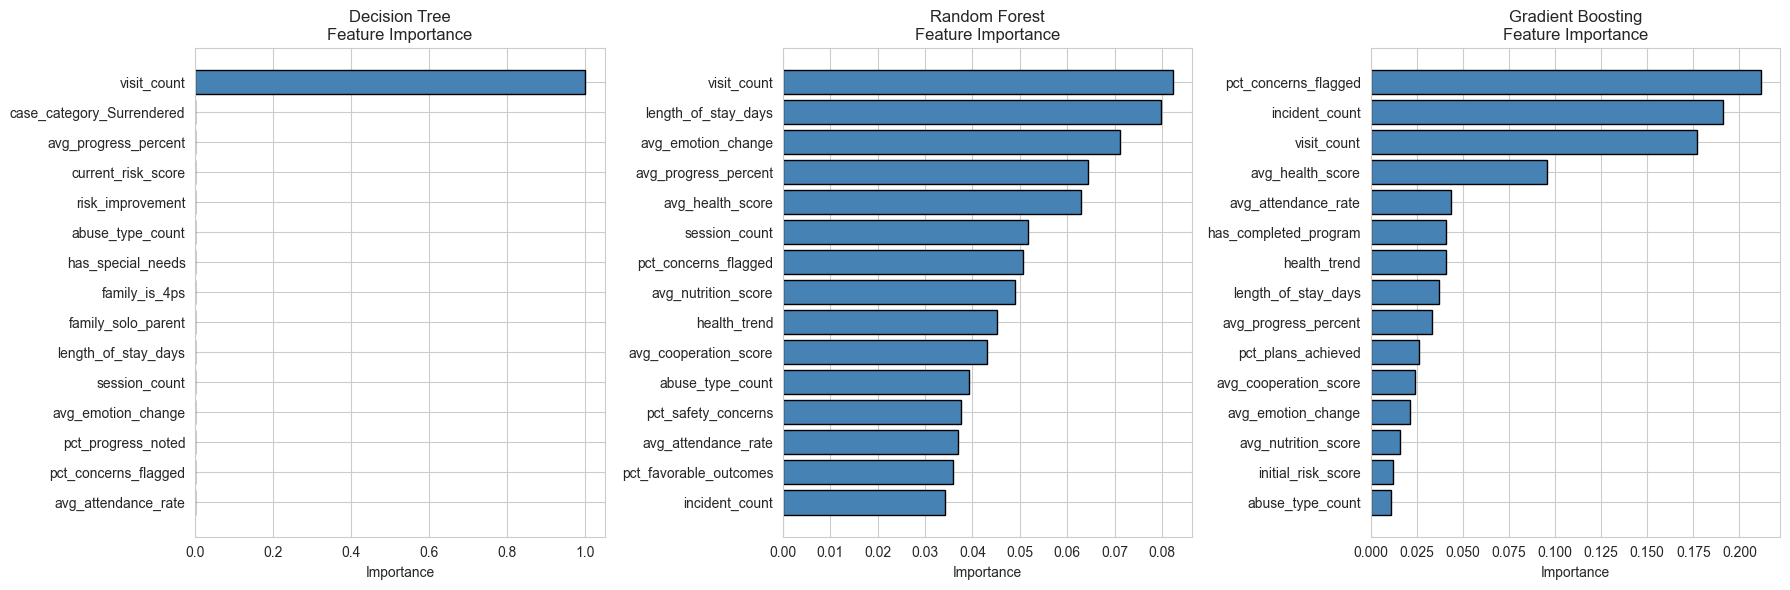

In [6]:
# ── Confusion matrix & classification report ───────────────────────────────
y_pred = best_tree_pipe.predict(X_full)
print("Full-data Classification Report (for reference -- NOT out-of-sample):")
print(classification_report(y, y_pred, target_names=['Not Ready', 'Ready']))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Ready', 'Ready'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix (Full Data -- Decision Tree)', fontsize=14)
plt.tight_layout()
plt.show()

print("Error cost analysis:")
print(f"  False Positives (predicted Ready but not): {cm[0, 1]}")
print(f"    -> RISK: Premature reintegration -- girl returns to unsafe environment")
print(f"  False Negatives (predicted Not Ready but is): {cm[1, 0]}")
print(f"    -> COST: Girl stays longer than needed -- impacts shelter capacity")
print(f"  True Positives: {cm[1, 1]} | True Negatives: {cm[0, 0]}")

# ── Feature importance from tree-based models ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, pipe) in zip(axes, [(n, p) for n, p in models.items() if n != 'Logistic Regression']):
    clf = pipe.named_steps['clf']
    importances = clf.feature_importances_
    names = all_feature_names[:len(importances)]
    sorted_idx = np.argsort(importances)[-15:]
    ax.barh([names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue', edgecolor='black')
    ax.set_title(f'{name}\nFeature Importance', fontsize=12)
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Causal Analysis — Ready vs Not Ready Comparisons

**What predicts readiness?** Based on the models above, the strongest predictors are likely:
- **Education progress** (avg_progress_percent, has_completed_program)
- **Health trends** (health_trend, avg_health_score)
- **Family cooperation** (avg_cooperation_score, pct_favorable_outcomes)
- **Plan achievement** (pct_plans_achieved)
- **Incident history** (incident_count, has_self_harm, has_runaway)

**Limitations:** ~60 rows, observational data, potential survivorship bias and temporal leakage.

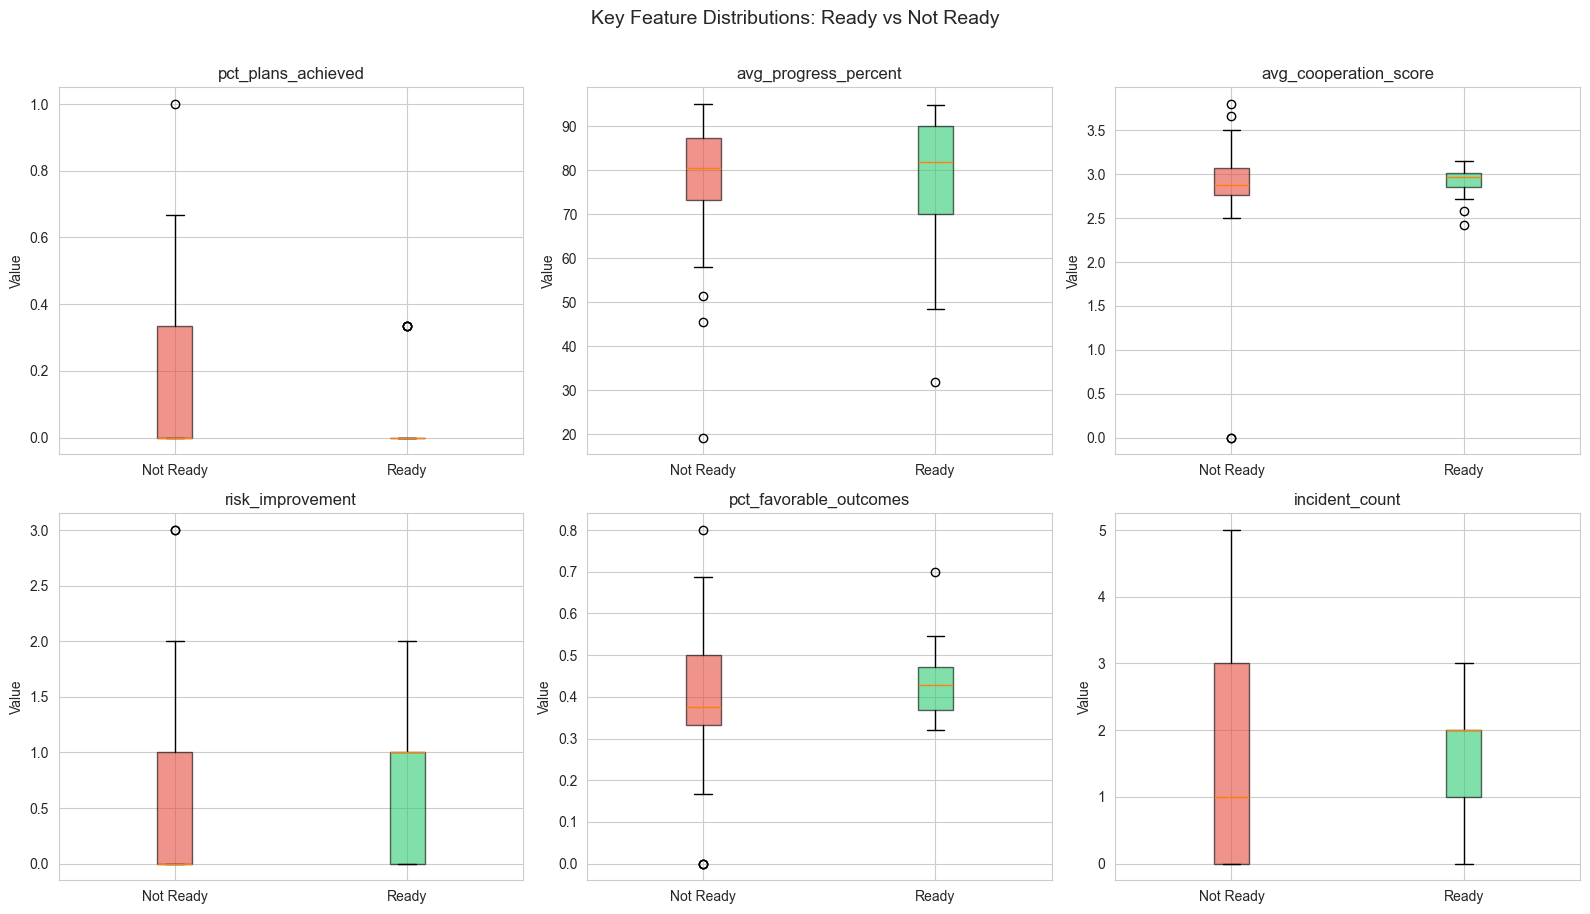

In [7]:
top_features = ['pct_plans_achieved', 'avg_progress_percent', 'avg_cooperation_score',
                'risk_improvement', 'pct_favorable_outcomes', 'incident_count']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(top_features):
    ax = axes[i // 3, i % 3]
    ready_vals = df[df['ready'] == 1][feat].dropna()
    not_ready_vals = df[df['ready'] == 0][feat].dropna()

    bp = ax.boxplot([not_ready_vals, ready_vals], labels=['Not Ready', 'Ready'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(feat, fontsize=12)
    ax.set_ylabel('Value')

plt.suptitle('Key Feature Distributions: Ready vs Not Ready', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Deployment Notes

**Integration:** Readiness scores are displayed on the **Caseload Inventory** page. Each resident's profile includes a reintegration readiness indicator that helps social workers and case managers make data-informed discharge decisions.

**Endpoint:** `POST /api/ml/readiness-score` accepts a resident ID and returns a readiness probability plus the decision tree path.

**How it works:**
1. Features are assembled from intervention plans, process recordings, and home visitation tables
2. The Decision Tree classifier provides both a prediction and an interpretable rule path
3. The React frontend displays the readiness score and key contributing factors on the resident profile

**Retraining:** Re-run quarterly as new resident outcomes are recorded.

## 10. Summary

**Key Findings:**
- The Decision Tree provides **interpretable rules** that staff can follow to understand why a resident is predicted ready or not.
- Education progress, plan achievement rate, and family cooperation are consistently among the top predictors across model types.
- With ~60 rows, all models face overfitting risk. LOO cross-validation provides the most honest performance estimates.

**Recommendations:**
1. Display the decision tree rules alongside each resident's readiness score so social workers understand the reasoning.
2. Prioritize tracking plan achievement rate and education progress as leading indicators.
3. Re-train as more residents complete reintegration to improve model stability.

---

*End of pipeline.*